# Colop: Cluster by CHUNK

In [1]:
import pandas as pd
import numpy as np
import plotly_express as px

# Get DOC

In [2]:
DOC = pd.read_csv("colop-CHAP.csv").set_index(['parte','capit'])

In [3]:
DOC.head()

parte_nombre                                       capit_nombre  \
parte capit                                                                   
1     1            NAB'E            ARE' UXE' OJER TZIJ WARAL K'ICHE' UB'I'   
      2            NAB'E                                 ARE UTZIJOXIK WA'E   
      3            NAB'E                      TA XWINAQIR K'U RI ULEW KUMAL   
      4            NAB'E          K'EJE K'UT UTIJTOB'EXIK CHIK WINAQ TZ'AQ,   
      5            NAB'E  K'ATE K'UT UB'IXIK RI' CHI KECH RI E NIK'WACHI...   

                                                       doc_str  n_chars  \
parte capit                                                               
1     1      ARE' UXE' OJER TZIJ WARAL K'ICHE' UB'I' Waral ...     1341   
      2      ARE UTZIJOXIK WA'E k'akatz'ininoq, k'akachamam...     1825   
      3      TA XWINAQIR K'U RI ULEW KUMAL Xa kitzij xk'oje...     3396   
      4      K'EJE K'UT UTIJTOB'EXIK CHIK WINAQ TZ'AQ, WINA...     1219   
      5      K'ATE K'UT UB'IXIK RI' CHI KECH RI E NIK'WACHI...     2436   

                    p  label  
parte capit                   
1     1      0.008013      1  
      2      0.010906      1  
      3      0.020293      1  
      4      0.007284      1  
      5      0.014557      1

In [4]:
round(DOC.p * 1000).astype(int).unstack(fill_value=0).style.background_gradient(axis=None)

capit,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
parte,,,,,,,,,,,,,,,
1,8,11,20,7,15,16,0,0,0,0,0,0,0,0,0
2,7,36,25,17,23,0,0,0,0,0,0,0,0,0,0
3,20,13,11,18,31,16,15,60,7,28,21,68,41,29,0
4,11,21,21,81,28,24,11,14,27,33,17,0,0,0,0
5,15,35,2,2,1,14,30,26,9,1,3,4,3,3,3


# Create CHUNK

In [5]:
bigline = (' '.join(DOC.doc_str.to_list())).split()
chunk_size = len(bigline) // 50
chunks = [bigline[i:i + chunk_size] for i in range(0, len(bigline), chunk_size)]

In [6]:
CHUNK = pd.DataFrame(chunks).apply(lambda x: ' '.join(map(str, x)), axis=1).to_frame('chunk_str')
CHUNK['level_1'] = CHUNK.index // 10
CHUNK['level_2'] = CHUNK.index % 10
CHUNK = CHUNK.reset_index(drop=True).set_index(['level_1', 'level_2'])

In [7]:
CHUNK.head()

chunk_str
level_1 level_2                                                   
0       0        ARE' UXE' OJER TZIJ WARAL K'ICHE' UB'I' Waral ...
        1        rach winaqirik uq'isisil, upachäjil uwach. K'e...
        2        xa pu chi'umarik. Mawi chi k'olol ujolom, xa j...
        3        kech. K'eje k'ut kikamisaxik, xeb'utik: xpe ni...
        4        wi rib' ri Wuqub' Kak'ix chi q'ijil, chi ik'il...

In [8]:
CHUNK.index.name = 'chunk_id'

In [9]:
CHUNK['n_chars'] = CHUNK.chunk_str.str.len()

In [10]:
CHUNK.head()

chunk_str  n_chars
level_1 level_2                                                            
0       0        ARE' UXE' OJER TZIJ WARAL K'ICHE' UB'I' Waral ...     3470
        1        rach winaqirik uq'isisil, upachäjil uwach. K'e...     3636
        2        xa pu chi'umarik. Mawi chi k'olol ujolom, xa j...     3498
        3        kech. K'eje k'ut kikamisaxik, xeb'utik: xpe ni...     3269
        4        wi rib' ri Wuqub' Kak'ix chi q'ijil, chi ik'il...     3350

# Create DTM

In [11]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, TfidfTransformer

In [12]:
count_engine = CountVectorizer(
    lowercase=True,
    analyzer='word',
    token_pattern=r"(?u)\b[a-z'][a-z']+\b",
    max_df=.99,
    min_df=5,    
    ngram_range = (1,1)
)

In [13]:
X = count_engine.fit_transform(CHUNK.chunk_str)

In [14]:
DTM = pd.DataFrame(X.toarray(), 
    columns=count_engine.get_feature_names_out(), 
    index=CHUNK.index)

In [15]:
DTM.head()

ab'aj  achij  aj  ajam  ajaw  ajawab  ajawarem  ajilan  \
level_1 level_2                                                           
0       0            1      0   0     0     0       0         0       0   
        1            0      0   0     0     0       0         0       0   
        2            0      1   0     5     0       0         0       0   
        3            3      0   0     1     0       0         0       0   
        4            0      0   0     1     0       0         0       0   

                 ajk'ajb  ajk'ixb  ...  xub'ina'j  xucha'xik  xuchax  xuk'am  \
level_1 level_2                    ...                                         
0       0              0        0  ...          0          0       0       0   
        1              0        0  ...          0          0       0       0   
        2              0        0  ...          0          0       0       0   
        3              0        0  ...          0          0       0       0   
        4              0        0  ...          0          0       0       0   

                 xul  xuxik  xwinaqir  xwinaqirik  xya  ya  
level_1 level_2                                             
0       0          1      1         1           1    0   0  
        1          0      0         2           1    0   0  
        2          0      0         0           0    0   0  
        3          0      0         0           0    0   0  
        4          0      0         0           0    0   1  

[5 rows x 460 columns]

# Create TFIDF

In [16]:
tfidf_engine = TfidfTransformer(norm='l2', use_idf=True)

In [17]:
TFIDF = pd.DataFrame(tfidf_engine.fit_transform(DTM).toarray(), columns=DTM.columns, index=DTM.index)

In [18]:
TFIDF.head()

ab'aj     achij   aj      ajam  ajaw  ajawab  ajawarem  \
level_1 level_2                                                              
0       0        0.026282  0.000000  0.0  0.000000   0.0     0.0       0.0   
        1        0.000000  0.000000  0.0  0.000000   0.0     0.0       0.0   
        2        0.000000  0.041013  0.0  0.205064   0.0     0.0       0.0   
        3        0.097506  0.000000  0.0  0.045774   0.0     0.0       0.0   
        4        0.000000  0.000000  0.0  0.032844   0.0     0.0       0.0   

                 ajilan  ajk'ajb  ajk'ixb  ...  xub'ina'j  xucha'xik  xuchax  \
level_1 level_2                            ...                                 
0       0           0.0      0.0      0.0  ...        0.0        0.0     0.0   
        1           0.0      0.0      0.0  ...        0.0        0.0     0.0   
        2           0.0      0.0      0.0  ...        0.0        0.0     0.0   
        3           0.0      0.0      0.0  ...        0.0        0.0     0.0   
        4           0.0      0.0      0.0  ...        0.0        0.0     0.0   

                 xuk'am       xul    xuxik  xwinaqir  xwinaqirik  xya  \
level_1 level_2                                                         
0       0           0.0  0.031076  0.02176  0.037014    0.042464  0.0   
        1           0.0  0.000000  0.00000  0.074603    0.042793  0.0   
        2           0.0  0.000000  0.00000  0.000000    0.000000  0.0   
        3           0.0  0.000000  0.00000  0.000000    0.000000  0.0   
        4           0.0  0.000000  0.00000  0.000000    0.000000  0.0   

                       ya  
level_1 level_2            
0       0        0.000000  
        1        0.000000  
        2        0.000000  
        3        0.000000  
        4        0.028458  

[5 rows x 460 columns]

# Create PCA / SVD

In [19]:
from sklearn.decomposition import TruncatedSVD as SVD, PCA, NMF

In [20]:
svd_engine = SVD(n_components=5)
SVD = pd.DataFrame(svd_engine.fit_transform(TFIDF), index=TFIDF.index)

In [21]:
pca_engine = PCA(n_components=5)
PCA = pd.DataFrame(pca_engine.fit_transform(TFIDF), index=TFIDF.index)

# Cluster

In [22]:
# M = TFIDF
M = SVD
# M = PCA # Best results

In [24]:
import sys
sys.path.append("../../local_lib/")
from hac2 import HAC
from sklearn.cluster import AgglomerativeClustering

In [25]:
metric = 'euclidean'
linkage = 'ward'

In [26]:
label_colors = {
    '1': 'lightgray',
    '2': 'pink',
    '3': 'lightblue',
    '4': 'lightgreen',
    '5': 'lightyellow',
    '': 'white'
}

In [27]:
fig2 = HAC(M)
fig2.linkage_method = linkage
fig2.dist_metric = metric

In [28]:
fig2.color_thresh = 1.2

<Figure size 640x480 with 0 Axes>

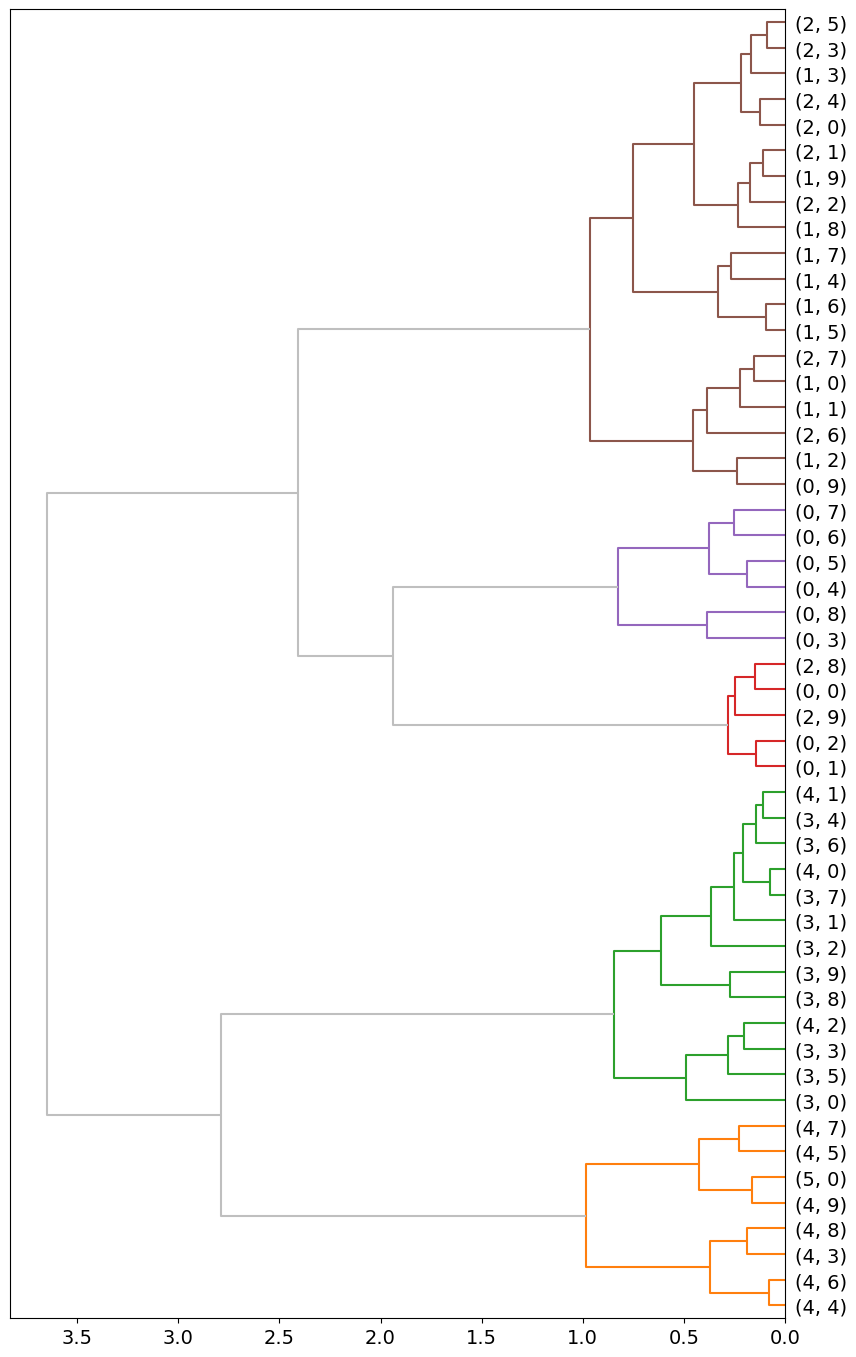

In [29]:
fig2.plot()

In [30]:
fig2.get_cluster_labels()
CHUNK['label'] = fig2.CLUSTER_LABELS.astype(str)

In [32]:
CHUNK.label.unstack(fill_value='').style.applymap(lambda x: 'background:' + label_colors[x])

level_2,0,1,2,3,4,5,6,7,8,9
level_1,,,,,,,,,,
0,2,2,2,3,3,3,3,3,3,1
1,1,1,1,1,1,1,1,1,1,1
2,1,1,1,1,1,1,1,1,2,2
3,4,4,4,4,4,4,4,4,4,4
4,4,4,4,5,5,5,5,5,5,5
5,5,,,,,,,,,


# Gloss LABEL

In [ ]:
LABEL = CHUNK.label.value_counts().to_frame('n')

In [ ]:
LABEL.sort_index().plot.bar(rot=0);

In [ ]:
LABEL['top_words'] = TFIDF.join(CHUNK.label).groupby('label').mean()\
    .apply(lambda x: ', '.join(x.sort_values(ascending=False).head(20).index.to_list()), axis=1)

In [ ]:
for idx, row in LABEL.iterrows():
    print(idx, row['top_words'])

# Inspect

In [ ]:
def show_chap(l1, l2):
    print(CHUNK.loc[(l1,l2)].chunk_str)

In [ ]:
show_chap(4,3)

# Observations

- These results corroborate the partitioning of the text by Tedlock and Colop.
- The repeated labels in parts I and IV (using converted label names) refer to the repetation of the theme of creating the first humans.
- Colop, Recinos, Tedlock, and many others all agree on a primary division of the text at this point -- the juncture between the apotheosis of the Two Boys as the Sun and Moon, and the creation of the first true humans as the Sun, Moon, and Stars appear in the sky.
- Upon inspection, each of these divisions reflect shifts in narrative time -- when _syuzhet_ moves to a different part of the _fabula_.
- We might propose a more precise partitioning based on these labels. This would include an overture and coda, two short parts that introduce and conclude the text.
- Methodologically, the chunking approach appears to produce better results than using the author's partitions. This may be due to the effects of length.

# Save

In [ ]:
CHUNK.to_csv("colop-CHUNK.csv", index=True)

In [ ]:
for df in [(TFIDF, 'TFIDF'), (PCA, 'PCA'), (SVD, 'SVD'), (DTM, 'DTM'), (LABEL, 'LABEL')]:
    df[0].to_csv(f"colop-CHUNK-{df[1]}.csv", index=True)